=== DATASET SMS SPAM ===
Shape : (5572, 2)

Distribution :
label
ham     4825
spam     747
Name: count, dtype: int64

Pourcentage spam : 13.41%

=== EXEMPLES ===

SMS HAM (normal) :
  → Go until jurong point, crazy.. Available only in bugis n great world la e buffet
  → Ok lar... Joking wif u oni...
  → U dun say so early hor... U c already then say...

SMS SPAM :
  → Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
  → FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some
  → WINNER!! As a valued network customer you have been selected to receivea £900 pr


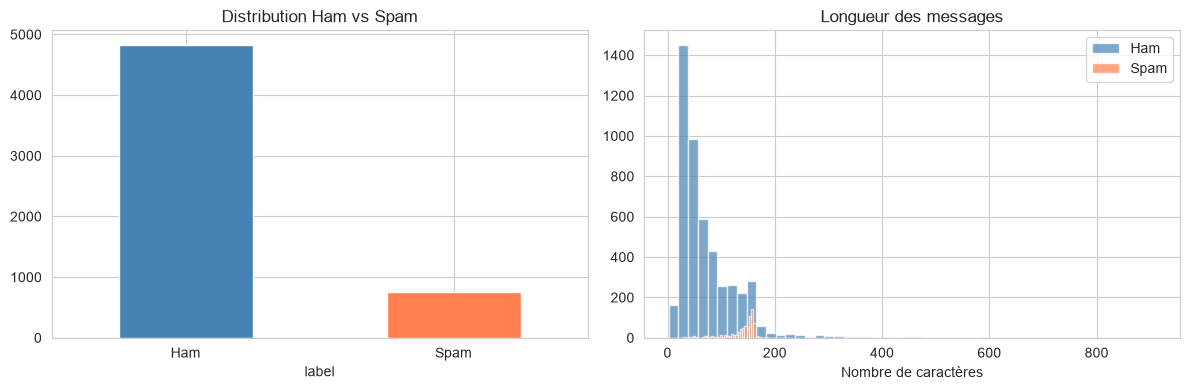


Longueur moyenne Ham  : 71 caractères
Longueur moyenne Spam : 139 caractères


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import re
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Charger les données
df = pd.read_csv("spam.csv", sep="\t", header=None, names=["label", "text"])

print("=== DATASET SMS SPAM ===")
print(f"Shape : {df.shape}")
print(f"\nDistribution :")
print(df["label"].value_counts())
print(f"\nPourcentage spam : {(df['label']=='spam').mean():.2%}")

print("\n=== EXEMPLES ===")
print("\nSMS HAM (normal) :")
for text in df[df["label"]=="ham"]["text"].head(3):
    print(f"  → {text[:80]}")

print("\nSMS SPAM :")
for text in df[df["label"]=="spam"]["text"].head(3):
    print(f"  → {text[:80]}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
df["label"].value_counts().plot(kind="bar", ax=axes[0],
                                 color=["steelblue", "coral"])
axes[0].set_title("Distribution Ham vs Spam")
axes[0].set_xticklabels(["Ham", "Spam"], rotation=0)

# Longueur des messages
df["length"] = df["text"].apply(len)
axes[1].hist(df[df["label"]=="ham"]["length"], bins=50, 
             alpha=0.7, color="steelblue", label="Ham")
axes[1].hist(df[df["label"]=="spam"]["length"], bins=50,
             alpha=0.7, color="coral", label="Spam")
axes[1].set_title("Longueur des messages")
axes[1].set_xlabel("Nombre de caractères")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nLongueur moyenne Ham  : {df[df['label']=='ham']['length'].mean():.0f} caractères")
print(f"Longueur moyenne Spam : {df[df['label']=='spam']['length'].mean():.0f} caractères")

In [3]:
# FEATURE ENGINEERING TEXTUEL
def extract_features(text):
    return {
        "length":        len(text),
        "n_digits":      sum(c.isdigit() for c in text),
        "n_upper":       sum(c.isupper() for c in text),
        "n_exclamation": text.count("!"),
        "n_dollars":     text.count("$") + text.count("£"),
        "pct_upper":     sum(c.isupper() for c in text) / max(len(text), 1),
        "has_free":      int("free" in text.lower()),
        "has_win":       int("win" in text.lower()),
        "has_prize":     int("prize" in text.lower()),
        "has_call":      int("call" in text.lower()),
        "has_urgent":    int("urgent" in text.lower()),
    }

features_df = pd.DataFrame([extract_features(t) for t in df["text"]])
print("=== FEATURES MANUELLES ===")
print(features_df.head())

# Comparaison ham vs spam
print("\n=== MOYENNES HAM vs SPAM ===")
features_df["label"] = df["label"]
print(features_df.groupby("label").mean().round(3))

# ENCODAGE
df["label_encoded"] = (df["label"] == "spam").astype(int)

X_text = df["text"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# PIPELINES avec TF-IDF
pipelines = {
    "Naive Bayes":         Pipeline([("tfidf", TfidfVectorizer()), 
                                      ("clf", MultinomialNB())]),
    "Logistic Regression": Pipeline([("tfidf", TfidfVectorizer()), 
                                      ("clf", LogisticRegression(max_iter=1000))]),
    "Linear SVM":          Pipeline([("tfidf", TfidfVectorizer()), 
                                      ("clf", LinearSVC())]),
    "Random Forest":       Pipeline([("tfidf", TfidfVectorizer()), 
                                      ("clf", RandomForestClassifier(n_estimators=100, 
                                                                      random_state=42))]),
}

print("\n=== COMPARAISON DES MODÈLES ===\n")
resultats = {}
for nom, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="f1")
    resultats[nom] = scores
    print(f"{nom:22s} → F1: {scores.mean():.4f} ± {scores.std():.4f}")

best_nom = max(resultats, key=lambda k: resultats[k].mean())
print(f"\n✅ Meilleur modèle : {best_nom}")

=== FEATURES MANUELLES ===
   length  n_digits  n_upper  n_exclamation  n_dollars  pct_upper  has_free  \
0     111         0        3              0          0   0.027027         0   
1      29         0        2              0          0   0.068966         0   
2     155        25       10              0          0   0.064516         1   
3      49         0        2              0          0   0.040816         0   
4      61         0        2              0          0   0.032787         0   

   has_win  has_prize  has_call  has_urgent  
0        0          0         0           0  
1        0          0         0           0  
2        1          0         0           0  
3        0          0         0           0  
4        0          0         0           0  

=== MOYENNES HAM vs SPAM ===
        length  n_digits  n_upper  n_exclamation  n_dollars  pct_upper  \
label                                                                    
ham     71.482     0.305     4.11          0

In [ ]:
# Entraîner le meilleur modèle
best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),    # unigrammes et bigrammes
        max_features=10000,
        strip_accents="unicode",
        analyzer="word",
        token_pattern=r"\b[a-zA-Z]\w+\b",
        sublinear_tf=True
    )),
    ("clf", LinearSVC(C=1.0))
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print("=== RÉSULTATS FINAUX — LINEAR SVM ===\n")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Matrice de confusion — Détecteur de Spam")
plt.ylabel("Réel"); plt.xlabel("Prédit")
plt.tight_layout()
plt.show()

# Tester sur de nouveaux messages
print("\n=== TEST SUR DE NOUVEAUX MESSAGES ===\n")
nouveaux_messages = [
    "Hey, are you coming to the party tonight?",
    "WINNER! You have been selected to receive a £1000 prize! Call now!",
    "Can you pick up some groceries on your way home?",
    "FREE entry in our competition! Text WIN to 87121 to claim your prize!",
    "I'll be late for dinner, traffic is terrible",
    "Congratulations! You've won a free iPhone! Click here to claim!",
    "Meeting rescheduled to 3pm tomorrow",
    "URGENT: Your account has been compromised. Call 0800 now!"
]

for msg in nouveaux_messages:
    pred = best_pipeline.predict([msg])[0]
    label = "🚫 SPAM" if pred == 1 else "✅ HAM"
    print(f"{label} → {msg[:60]}")

# Mots les plus importants
print("\n=== MOTS LES PLUS INDICATIFS DU SPAM ===")
feature_names = best_pipeline.named_steps["tfidf"].get_feature_names_out()
coefs = best_pipeline.named_steps["clf"].coef_[0]
top_spam = sorted(zip(coefs, feature_names), reverse=True)[:15]
print("Top 15 mots spam :")
for coef, word in top_spam:
    print(f"  {word:20s} : {coef:.3f}")